# CELL 1 — Environment Setup & Imports

In [1]:
import sys
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display
import ipywidgets as widgets

# Add CellViT repo to PYTHONPATH
sys.path.append("../CellViT-plus-plus")

# Using the official CellViT inference utilities
from cellvit.training.evaluate.inference_cellvit_experiment_pannuke import InferenceCellViT
from cellvit.training.trainer.trainer_cellvit import CellViTTrainer


# CELL 2 — Load input image (256x256 PNG)


Loaded image: /projectnb/ec500kb/projects/Fall_2025_Projects/Project_2/AI-guided-whole-slide-imaging-analysis/AI-GUIDED-CLEAN/ProcessedDataset/v1_40x_area20_2/patches_cellvit_p256_pannuke/fold0/images/TCGA-55-1594-01Z-00-DX1_001_0_768.png
Shape: (256, 256, 3)
Dtype: uint8
Min / Max: 19 255


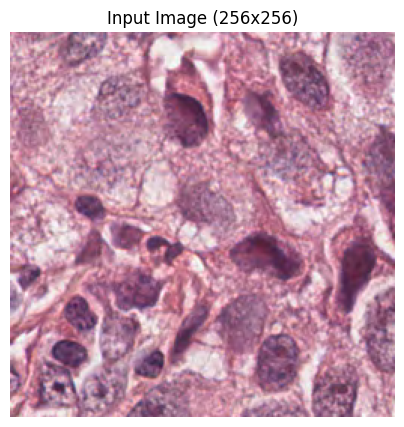

In [2]:
IMAGE_PATH = "/projectnb/ec500kb/projects/Fall_2025_Projects/Project_2/AI-guided-whole-slide-imaging-analysis/AI-GUIDED-CLEAN/ProcessedDataset/v1_40x_area20_2/patches_cellvit_p256_pannuke/fold0/images/TCGA-55-1594-01Z-00-DX1_001_0_768.png"

assert os.path.exists(IMAGE_PATH), f"Image not found: {IMAGE_PATH}"

img = Image.open(IMAGE_PATH).convert("RGB")
img_np = np.array(img)

print("Loaded image:", IMAGE_PATH)
print("Shape:", img_np.shape)
print("Dtype:", img_np.dtype)
print("Min / Max:", img_np.min(), img_np.max())

plt.figure(figsize=(5,5))
plt.imshow(img_np)
plt.title("Input Image (256x256)")
plt.axis("off")
plt.show()


# CELL 3&4 

## A- Load downloaded log folder
## B- Download log folder from HuggingFace

In [ ]:
#A- Load downloaded log folder
 
import sys
import torch

from cellvit.training.evaluate.inference_cellvit_experiment_pannuke import InferenceCellViT

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# --- CHANGE THIS TO YOUR LOG FOLDER PATH ---
RUN_DIR = "/projectnb/ec500kb/projects/Fall_2025_Projects/Project_2/AI-guided-whole-slide-imaging-analysis/AI-GUIDED-CLEAN/ProcessedDataset/v1_40x_area20_2/patches_cellvit_p256_pannuke/logs_local_berk/2025-12-05T191217_film256"

CHECKPOINT_NAME = "model_best.pth" # Change this if necessary
MAGNIFICATION = 40  # same as training

# Build inference utility
inference = InferenceCellViT(
    run_dir=RUN_DIR,
    gpu=0,
    checkpoint_name=CHECKPOINT_NAME,
    magnification=MAGNIFICATION,
)

# This gives:
# - trained_model: the Virchow model already restored
# - val_loader:    the SAME transforms used during training
# - dataset_config: nuclei/tissue class mapping
trained_model, val_loader, dataset_config = inference.setup_patch_inference()

trained_model = trained_model.to(device).eval()

print("Validation loader length:", len(val_loader))
print("Dataset config:", dataset_config)


Using device: cuda
Loaded run: /projectnb/ec500kb/projects/Fall_2025_Projects/Project_2/AI-guided-whole-slide-imaging-analysis/AI-GUIDED-CLEAN/ProcessedDataset/v1_40x_area20_2/patches_cellvit_p256_pannuke/logs_local_berk/2025-12-05T191217_film256
Loading best model from /projectnb/ec500kb/projects/Fall_2025_Projects/Project_2/AI-guided-whole-slide-imaging-analysis/AI-GUIDED-CLEAN/ProcessedDataset/v1_40x_area20_2/patches_cellvit_p256_pannuke/logs_local_berk/2025-12-05T191217_film256/checkpoints/model_best.pth
<All keys matched successfully>
There was no test set provided. We now use the validation dataset for testing
Performing Inference on test set: [1]
Validation loader length: 2
Dataset config: {'name': 'TCGA', 'magnification': 40, 'patch_size': 256, 'num_classes': 1, 'stain_normalized': False, 'description': 'TCGA Lung patches prepared for CellViT fine-tuning', 'tissue_types': {'Lung': 0}, 'nuclei_types': {'background': 0, 'epithelial': 1, 'lymphocyte': 2, 'macrophage': 3, 'neutroph

# CELL 4 — Load CellViT Model via Hugging Face

In [5]:
# B- Download log folder from HuggingFace

import torch
from huggingface_hub import snapshot_download
from cellvit.training.evaluate.inference_cellvit_experiment_pannuke import InferenceCellViT

# -------------------------------------------------
# Device
# -------------------------------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# -------------------------------------------------
# Hugging Face model run
# -------------------------------------------------
HF_REPO_ID = "BerkTuzcuBU/CellViT-FiLM-256-Run"

RUN_DIR = snapshot_download(
    repo_id=HF_REPO_ID,
    local_dir="./runs/cellvit_film_256",
    local_dir_use_symlinks=False,
)

print("Model run downloaded to:", RUN_DIR)

# -------------------------------------------------
# Inference configuration
# -------------------------------------------------
CHECKPOINT_NAME = "model_best.pth"
MAGNIFICATION = 40   # must match training

# -------------------------------------------------
# Build inference utility
# -------------------------------------------------
inference = InferenceCellViT(
    run_dir=RUN_DIR,
    gpu=0 if device == "cuda" else None,
    checkpoint_name=CHECKPOINT_NAME,
    magnification=MAGNIFICATION,
)

# -------------------------------------------------
# Restore model + validation loader
# (uses EXACT training transforms)
# -------------------------------------------------
trained_model, val_loader, dataset_config = inference.setup_patch_inference()

trained_model = trained_model.to(device).eval()

print("Validation loader length:", len(val_loader))
print("Nuclei types:", dataset_config["nuclei_types"])


Using device: cpu


Fetching 10 files:   0%|          | 0/10 [00:00<?, ?it/s]

.gitattributes: 0.00B [00:00, ?B/s]

config.yaml: 0.00B [00:00, ?B/s]

inference.log:   0%|          | 0.00/668 [00:00<?, ?B/s]

...

checkpoints/model_best.pth:   0%|          | 0.00/8.60G [00:00<?, ?B/s]

inference.log.1:   0%|          | 0.00/901 [00:00<?, ?B/s]

inference.log.5:   0%|          | 0.00/530 [00:00<?, ?B/s]

logs.log: 0.00B [00:00, ?B/s]

OSError: [Errno 122] Disk quota exceeded

# Load checkpoint from RUN_DIR

In [4]:
ckpt = torch.load(RUN_DIR+"/checkpoints/model_best.pth", map_location="cpu", weights_only=False)
print(ckpt["arch"])


CellViTSAMRosieFiLM


# CELL 4 — Inference using with EXACT Training Transforms + Postprocessing

binary min/max: 2.3396566e-07 0.99999964
hv range: -1.010793 1.0702363
unique instances: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]


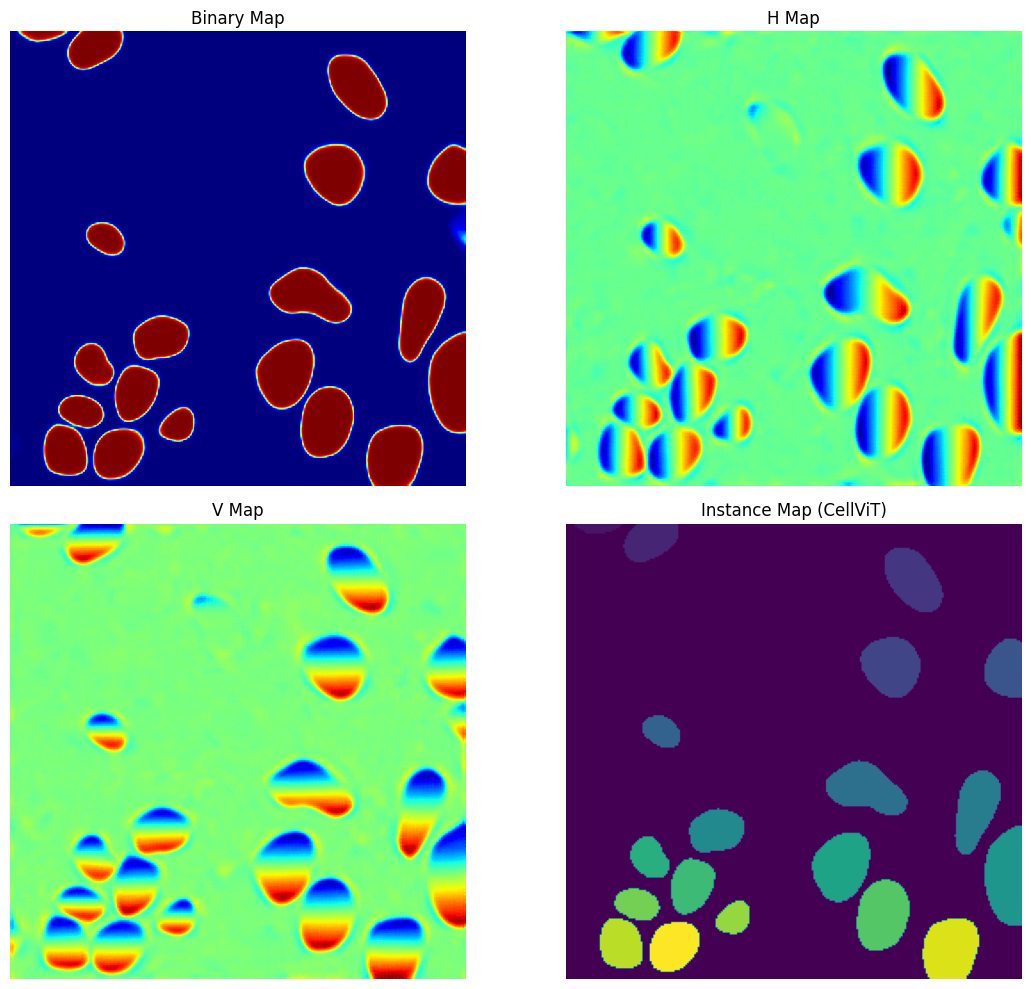

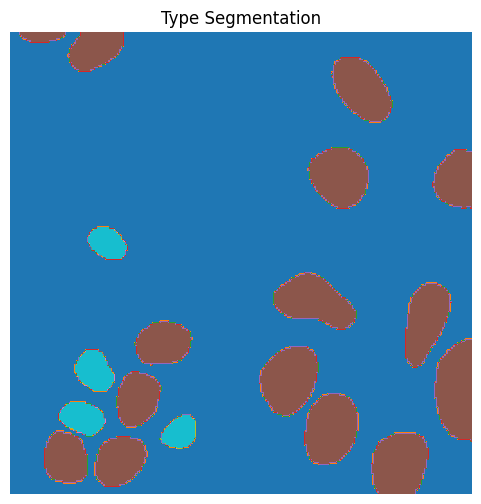

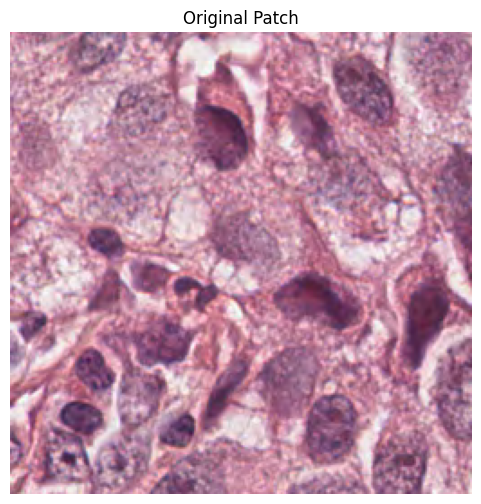

In [ ]:
from PIL import Image
import numpy as np
import torch

# ------------------- 1) Load your image -------------------
img_np   = np.array(img)

# Build a dummy trainer just for postprocessing
dummy_opt = torch.optim.SGD(trained_model.parameters(), lr=0.1)
dummy_sched = torch.optim.lr_scheduler.StepLR(dummy_opt, step_size=1000, gamma=1.0)

trainer = CellViTTrainer(
    model=trained_model,
    loss_fn_dict={},
    optimizer=dummy_opt,
    scheduler=dummy_sched,
    device=device,
    logger=inference.logger,
    logdir=RUN_DIR,
    num_classes=len(dataset_config["nuclei_types"]),
    dataset_config=dataset_config,
    experiment_config={},
    early_stopping=None,
    log_images=False,
    magnification=MAGNIFICATION,
    mixed_precision=False,
)

# ------------------- 2) Apply SAME transforms as val set -------------------
ds  = val_loader.dataset
tfm = getattr(ds, "transforms", None) or getattr(ds, "transform", None)

if tfm is None:
    raise RuntimeError("Dataset has no transform attribute.")

# Albumentations transform
try:
    transformed = tfm(image=img_np)
    img_t = transformed["image"]
except TypeError:
    # Torchvision transform
    img_t = tfm(img)

# ------------------- 3) Ensure output is a CHW torch tensor -------------------
if isinstance(img_t, np.ndarray):
    if img_t.ndim == 3 and img_t.shape[-1] == 3:
        img_t = torch.from_numpy(img_t).permute(2,0,1)
    else:
        img_t = torch.from_numpy(img_t)
elif isinstance(img_t, torch.Tensor):
    if img_t.ndim == 3 and img_t.shape[-1] == 3:
        img_t = img_t.permute(2,0,1)
else:
    raise TypeError("Unexpected transform output type")

# Make batch
img_batch = img_t.unsqueeze(0).to(device)

# ------------------- 4) Model + Postprocessing -------------------
with torch.no_grad():
    out = trained_model(img_batch)

processed = trainer.unpack_predictions(out)

binary_map = processed.nuclei_binary_map[0,1].cpu().numpy()
hv_map     = processed.hv_map[0].cpu().numpy()
inst_map   = processed.instance_map[0].cpu().numpy().astype(int)
type_map   = torch.argmax(processed.nuclei_type_map, dim=1)[0].cpu().numpy()

print("binary min/max:", binary_map.min(), binary_map.max())
print("hv range:", hv_map.min(), hv_map.max())
print("unique instances:", np.unique(inst_map)[:20])

# ------------------- 5) Visualize -------------------
plt.figure(figsize=(12,10))

plt.subplot(2,2,1)
plt.imshow(binary_map, cmap="jet")
plt.title("Binary Map")
plt.axis("off")

plt.subplot(2,2,2)
plt.imshow(hv_map[0], cmap="jet")
plt.title("H Map")
plt.axis("off")

plt.subplot(2,2,3)
plt.imshow(hv_map[1], cmap="jet")
plt.title("V Map")
plt.axis("off")

plt.subplot(2,2,4)
plt.imshow(inst_map)
plt.title("Instance Map (CellViT)")
plt.axis("off")

plt.tight_layout()
plt.show()

plt.figure(figsize=(6,6))
plt.imshow(type_map, cmap="tab10")
plt.title("Type Segmentation")
plt.axis("off")
plt.show()

# -------------------- Original Image -----------------
plt.figure(figsize=(6,6))
plt.imshow(img)
plt.title("Original Patch")
plt.axis("off")
plt.show()


# CELL 6 — Overlay Results on the Original Image (with legend)


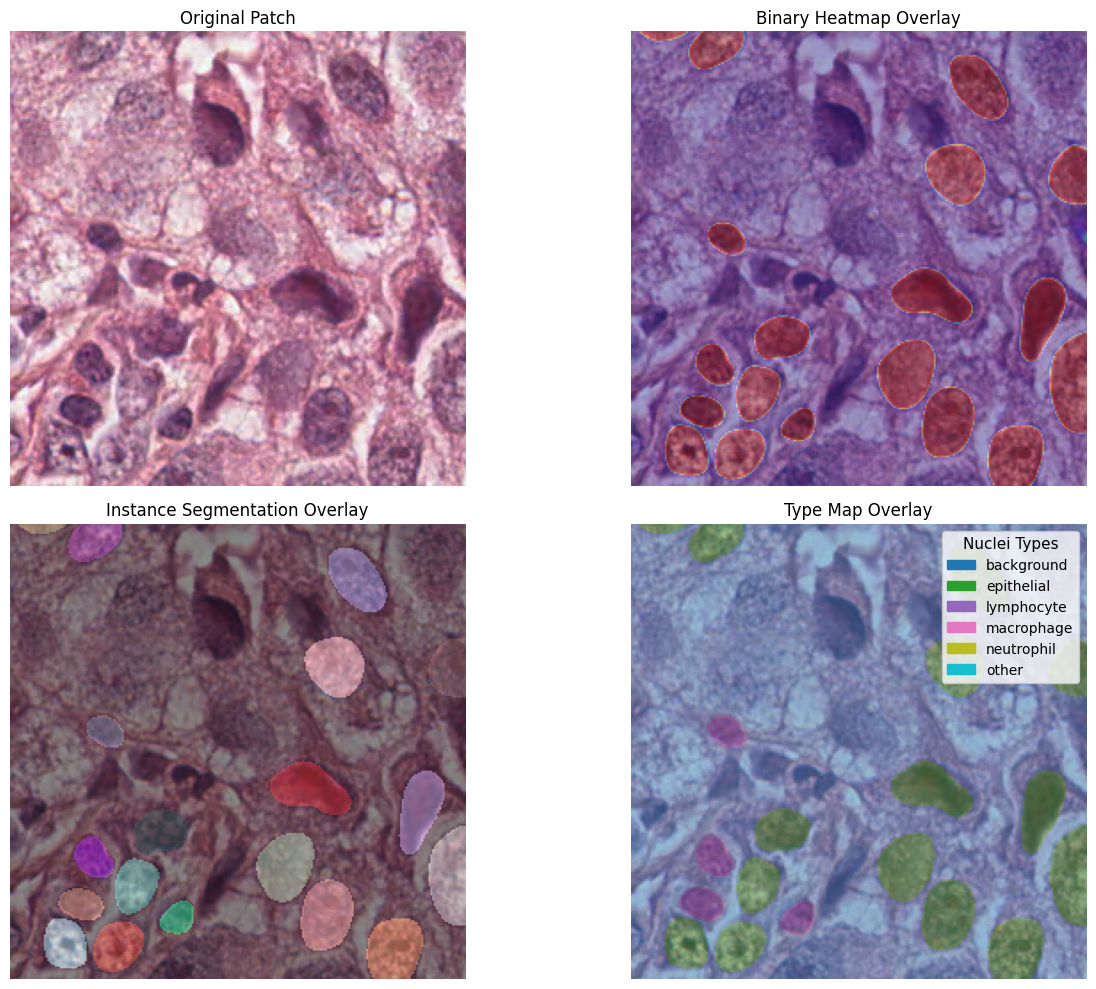

In [6]:

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# --- 0) Build legend colors from dataset_config automatically ---
nuclei_types = dataset_config["nuclei_types"]        # {"background":0, "epithelial":1, ...}
num_classes  = len(nuclei_types)
cmap = plt.get_cmap("tab10")

# map class name → RGB color (0–255)
type_to_color = {
    cls_name: (np.array(cmap(cls_id / max(1, num_classes-1))[:3]) * 255).astype(np.uint8)
    for cls_name, cls_id in nuclei_types.items()
}

# --- 1) Original RGB image ---
orig = np.array(img).copy()   # use original uploaded image
H, W = binary_map.shape
orig_resized = cv2.resize(orig, (W, H))

# --- 2) Instance segmentation overlay ---
inst_colored = np.zeros((H, W, 3), dtype=np.uint8)
unique_ids = np.unique(inst_map)

for uid in unique_ids:
    if uid == 0: 
        continue
    color = np.random.randint(0, 255, size=3)
    inst_colored[inst_map == uid] = color

overlay_inst = cv2.addWeighted(orig_resized, 0.55, inst_colored, 0.45, 0)

# --- 3) Binary heatmap overlay ---
binary_norm  = (binary_map * 255).astype(np.uint8)
binary_color = cv2.applyColorMap(binary_norm, cv2.COLORMAP_JET)
binary_color = cv2.cvtColor(binary_color, cv2.COLOR_BGR2RGB)

overlay_binary = cv2.addWeighted(orig_resized, 0.65, binary_color, 0.35, 0)

# --- 4) Type map overlay ---
type_color_map = np.zeros((H, W, 3), dtype=np.uint8)
for cls_name, cls_id in nuclei_types.items():
    mask = type_map == cls_id
    type_color_map[mask] = type_to_color[cls_name]

overlay_type = cv2.addWeighted(orig_resized, 0.55, type_color_map, 0.45, 0)

# --- 5) Build legend patches ---
legend_entries = []
for cls_name, rgb in type_to_color.items():
    patch = mpatches.Patch(color=rgb/255.0, label=cls_name)
    legend_entries.append(patch)

# --- 6) Plot everything ---
fig, ax = plt.subplots(2, 2, figsize=(14, 10))

ax[0,0].imshow(orig_resized)
ax[0,0].set_title("Original Patch")
ax[0,0].axis("off")

ax[0,1].imshow(overlay_binary)
ax[0,1].set_title("Binary Heatmap Overlay")
ax[0,1].axis("off")

ax[1,0].imshow(overlay_inst)
ax[1,0].set_title("Instance Segmentation Overlay")
ax[1,0].axis("off")

ax[1,1].imshow(overlay_type)
ax[1,1].set_title("Type Map Overlay")
ax[1,1].axis("off")

# Add legend to the Type Map subplot
ax[1,1].legend(
    handles=legend_entries,
    loc="upper right",
    title="Nuclei Types",
    fontsize=10,
    title_fontsize=11,
    frameon=True
)

plt.tight_layout()
plt.show()
